In [1]:
# моделирование идеального газа,
# состоящего из заданного числа частиц

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# импорт из библиотеки scipy.optimize
# функции curve_fit
from scipy.optimize import curve_fit


In [ ]:
# Ячейка № 2

# задание функции, возвращающей:
# мгновенные значения скорости частицы идеального газа;
# энергии идеального газа;
# отношения числа принятых изменений значений
# энергии идеального газа к силу шагов
# метода Монте-Карло
def Ideal_Gas_Same_Particle(Vel, T, dV_max, N_Trial, N_Particle):
    # Vel - начальная скорость частиц идеального газа
    # T - температура газа
    # dV_max - значение, определяющее диапазон
    #          изменения скорости ([-dV_max /2, dV_max /2])

    # инициализация массива, используемого
    # для хранения мгновенных значений
    # энергии идеального газа
    E_System = np.zeros(N_Trial * N_Particle + 1)

    # инициализация массива, используемого
    # для хранения мгновенных значений
    # скорости частицы
    V_Particle = Vel * np.ones(N_Particle)

    # вычисление начальной энергии
    # идеального газа
    E_System[0] = np.dot(V_Particle, V_Particle) / 2

    E_Old = E_System[0]

    # инициализация счетчика числа принятых
    # изменений скорости частицы и
    # энергии идеального газа
    N_Accept = 0

    # инициализация массива V, используемого
    # для хранения значений скоростей частиц
    # моделируемой системы на каждом шаге
    # метода Монте-Карло
    V = np.zeros([N_Particle, N_Trial * N_Particle + 1])
    V[:, 0] = V_Particle[:]
    k = 0

    # задание функции, реализующей алгоритма Метрополиса
    for i in range(N_Trial):
        for j in range(N_Particle):
            # задание случайной величины изменения скорости частицы
            dV = random.uniform(-dV_max / 2, dV_max / 2)
            V_Temp = V_Particle[j]

            # вычисление измененного значения скорости
            V_Particle[j] = V_Particle[j] + dV

            # вычисление измененного значения энергии
            E_New = np.dot(V_Particle, V_Particle) / 2
            dE = E_New - E_Old

            if dE > 0:
                # сравнение вероятности перехода
                # в новое состояние со случайным числом,
                #  генерируемым в соответствие
                # с равномерным законом распределения на интервале [0,1]
                if np.exp(-dE / T) >= random.uniform(0, 1):
                    # изменения принимаются
                    N_Accept = N_Accept + 1
                    E_Old = E_New
                else:
                    V_Particle[j] = V_Temp
            else:
                # dE < 0, поэтому изменения принимаются
                N_Accept = N_Accept + 1
                E_Old = E_New  # сохранение мгновенного значения
            k = k + 1

            # сохранение мгновенного значения
            # энергии идеального газа,
            # приходящегося на одну частицу
            E_System[k] = E_Old / N_Particle
            # сохранение мгновенного значения
            # скорости каждой частицы идеального газа
            V[:, k] = V_Particle[:]

    return V, E_System, N_Accept / (N_Trial * N_Particle)

In [3]:
# Ячейка № 3

# вычисление мгновенных значений энергии
# одномерного идеального газа, состоящего
# из N_Particle частиц, и их мгновенных скоростей

# инициализация генератора случайных чисел
random.seed()

# задание числа частиц идеального газа
N_Particle = 80

# задание начального значения
# скорости частиц идеального газа
Vel = 0

# задание температуры идеального газа
T = 5

# задание значения,
# определяющего диапазон пробного
# изменения скорости ([-dV_max /2, dV_max /2])
dV_max = 0.5

# задание числа шагов алгоритма Метрополиса
N_Trial = 10**4

# вычисление мгновенных значений:
# скорости частицы идеального газа (Vel);
# энергии идеального газа (E_System);
# отношения числа принятых изменений значений
# энергии идеального газа к числу шагов
# алгоритма Метрополиса
[V, E_System, Accept] = Ideal_Gas_Same_Particle(Vel, T, dV_max, N_Trial, N_Particle)


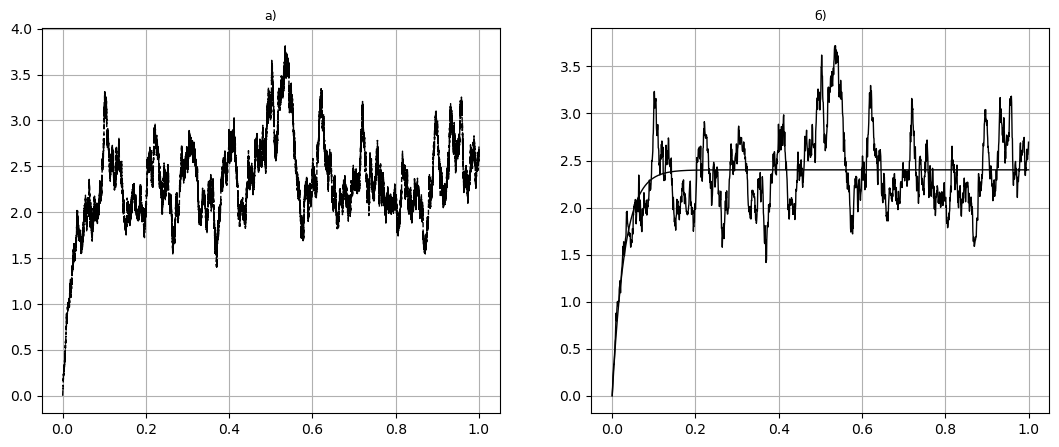

In [4]:
# Ячейка № 4

# визуализация зависимости мгновенной
# мгновенной энергии идеального газа,
# приходящейся на одну частицу от времени,
# и аппроксимации данной зависимости

fig = plt.figure(figsize=(13, 11))

# визуализация последовательности,
# составленной из мгновенных значений
# энергии системы
ax = plt.subplot(2, 2, 1)

# создаем массив номеров
# выполненных шагов алгоритма Метрополиса,
# нормированных на значение произведения
# числа частиц идеального газа на
# число шагов алгоритма Метрополиса

j = []
for i in range(0, len(E_System)):
    j.append(i / (N_Trial * N_Particle))


# визуализация зависимости
# мгновенных значений энергии от
# нормированного номера шага
# алгоритма Метрополиса
plt.plot(np.asarray(j), E_System, "--k", lw=1)
plt.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация прореженной с шагом
# 500 зависимости мгновенных значений
# от нормированного номера шага
# алгоритма Метрополиса и ее аппроксимации
ax = plt.subplot(2, 2, 2)
j2 = []
x2 = []
for i in range(0, len(E_System), 5 * 10**2):
    j2.append(i)
    x2.append(i / (N_Trial * N_Particle))

# перемещение из массива E_System
# в массив E_System2
# каждого 500-го значения энергии
E_System2 = E_System[j2]


# вычисление коэффициентов a, b, c
# аппроксимации прореженной с шагом
# 500 зависимости мгновенных значений
# энергии идеального газа на одну частицу
# от нормированного номера шага
# алгоритма Метрополиса
# функцией вида a * (1 - exp(-b * x))
Coeff = curve_fit(
    lambda t, a, b: a * (1 - np.exp(-b * t)),
    np.asarray(x2),
    E_System2,
    bounds=(0, [2000, 100]),
)
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * (1 - np.exp(-b * x))


# вычисление значений аппроксимирующей функции
y2 = func(np.asarray(j), Сoeff2[0], Сoeff2[1])
plt.plot(x2, E_System2, "-k", lw=1)
plt.plot(j, y2, "-k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)

plt.show()